🚀 เริ่มการฝึกสอนโมเดล (2,000 รอบ) ด้วย SGD Optimizer...
✅ ฝึกสอนเสร็จสิ้น! ค่า Loss สุดท้าย: 0.000167

--- ผลการทำนายวันที่ 8, 9, 10 ---
Day  8 | ค่าจริง: 3.80 | ค่าพยากรณ์: 3.81 | Error: 0.17%
Day  9 | ค่าจริง: 3.70 | ค่าพยากรณ์: 3.78 | Error: 2.10%
Day 10 | ค่าจริง: 3.50 | ค่าพยากรณ์: 3.73 | Error: 6.55%


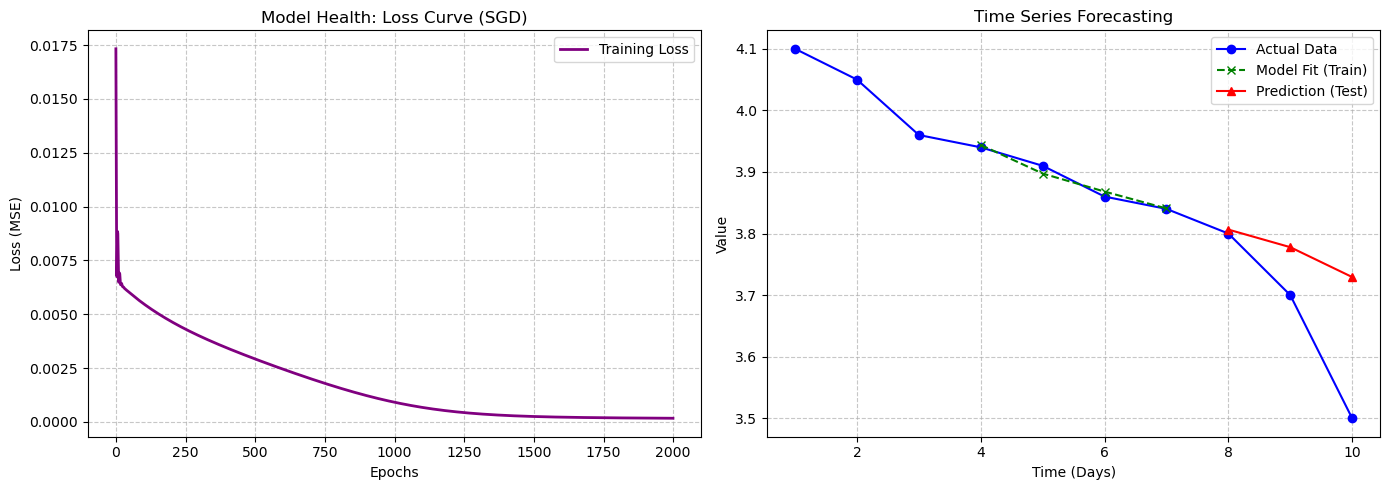

In [9]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import regularizers

# ==========================================
# 1. ⚙️ สวิตช์เลือกชุดข้อมูล (Dataset Switch)
# ==========================================
# (เอาเครื่องหมาย # ออกหน้าชุดข้อมูลที่คุณต้องการทดสอบเพียงชุดเดียว)

# บ่อที่ 1: ลักษณะแนวโน้มลดลงเป็นเส้นตรง
do_data = np.array([4.10, 4.05, 3.96, 3.94, 3.91, 3.86, 3.84, 3.80, 3.70, 3.50]).reshape(-1, 1)

# บ่อที่ 2: ลักษณะแกว่งตัวผันผวนรุนแรง (จุดปราบเซียน)
# do_data = np.array([4.35, 4.50, 4.22, 4.16, 4.35, 4.08, 4.35, 4.49, 4.20, 4.20]).reshape(-1, 1)

# บ่อที่ 3: ลักษณะสถานการณ์ปกติแต่แกว่งตัวไร้ทิศทาง
# do_data = np.array([4.22, 4.31, 4.08, 4.51, 4.36, 4.36, 3.90, 4.08, 4.20, 4.30]).reshape(-1, 1)


# ==========================================
# 2. 🧹 การเตรียมและแปลงสเกลข้อมูล (Preprocessing)
# ==========================================
scaler = MinMaxScaler(feature_range=(0, 1))
do_scaled = scaler.fit_transform(do_data).flatten()

# สร้าง Sliding Window = 3 (มองอดีต 3 วัน)
def create_dataset(data, window_size=3):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 3
X, y = create_dataset(do_scaled, window_size)

# แบ่งข้อมูล: 4 ชุดแรกสำหรับสอน (Train), 3 ชุดหลังสำหรับทดสอบ (Test)
X_train, y_train = X[:4], y[:4]
X_test, y_test = X[4:], y[4:]


# ==========================================
# 3. 🧠 โครงสร้างสมอง AI (Architecture: Back to Basics)
# ==========================================
model = Sequential()
model.add(Input(shape=(window_size,)))

# ปลดเบรก L2 ออก สำหรับชุดข้อมูลที่ไม่มีความผันผวนอย่างบ่อที่ 1
model.add(Dense(8, activation='tanh'))
model.add(Dense(4, activation='sigmoid'))
model.add(Dense(1, activation='linear'))

# ใช้ L2 = 0.01 เป็นตัวถ่วงน้ำหนัก (เบรก) ป้องกันไม่ให้ AI ท่องจำอดีตมากเกินไป
# model.add(Dense(8, activation='tanh', kernel_regularizer=regularizers.l2(0.01)))
# model.add(Dense(4, activation='sigmoid', kernel_regularizer=regularizers.l2(0.01)))
# model.add(Dense(1, activation='linear'))

# ใช้ SGD Optimizer (สมองเดินช้า แต่เกลี่ยน้ำหนักได้เสถียรกว่าในข้อมูลขนาดเล็ก)
optimizer = SGD(learning_rate=0.05, momentum=0.8)
model.compile(loss='mean_squared_error', optimizer=optimizer)


# ==========================================
# 4. 🏋️ การฝึกสอน (Training)
# ==========================================
print("🚀 เริ่มการฝึกสอนโมเดล (2,000 รอบ) ด้วย SGD Optimizer...")
history = model.fit(X_train, y_train, epochs=2000, verbose=0)
print(f"✅ ฝึกสอนเสร็จสิ้น! ค่า Loss สุดท้าย: {history.history['loss'][-1]:.6f}")


# ==========================================
# 5. 📊 การพยากรณ์และแสดงผลลัพธ์ (Evaluation)
# ==========================================
predictions_scaled = model.predict(X_test, verbose=0)
predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print("\n--- ผลการทำนายวันที่ 8, 9, 10 ---")
for i, (actual, pred) in enumerate(zip(y_test_actual.flatten(), predictions.flatten())):
    day = 8 + i
    error = abs((actual - pred) / actual) * 100
    print(f"Day {day:2d} | ค่าจริง: {actual:.2f} | ค่าพยากรณ์: {pred:.2f} | Error: {error:.2f}%")


# ==========================================
# 6. 📈 การวาดกราฟ (Visualization)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# กราฟซ้าย: ตรวจสุขภาพโมเดล
ax1.plot(history.history['loss'], color='purple', linewidth=2, label='Training Loss')
ax1.set_title('Model Health: Loss Curve (SGD)')
# ax1.set_title('Model Health: Loss Curve (SGD + L2)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (MSE)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# กราฟขวา: เทียบผลการพยากรณ์
ax2.plot(range(1, 11), do_data, marker='o', color='blue', label='Actual Data')
train_pred = scaler.inverse_transform(model.predict(X_train, verbose=0))
ax2.plot(range(4, 8), train_pred, marker='x', linestyle='--', color='green', label='Model Fit (Train)')
ax2.plot(range(8, 11), predictions, marker='^', linestyle='-', color='red', label='Prediction (Test)')
ax2.set_title('Time Series Forecasting')
ax2.set_xlabel('Time (Days)')
ax2.set_ylabel('Value')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()